In [1]:
# !uv run python -m ensurepip --upgrade
# !python -m spacy download en_core_web_sm

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
import json
from pathlib import Path

from src.common import SV_COL
from src.plots import (
    plot_attribution_trend,
    plot_derivative,
    plot_importance_cumsum_and_derivative,
    plot_token_count_distribution,
)
from src.sgpa import FIGURES_DIR, STATS_DIR
from src.stats import (
    perform_advanced_ttest,
)
from src.transformations import calculate_normalized_entropy, normalize_lengths

# Tests and preparation

In [ ]:
LEM_RUNS_ROOT = Path("../interspeech/outputs/lem_runs")
EXPERIMENT_SETS = {
    "rebuttal_single_sentence_1k_sgpa": "single_sentence_1k",
    "rebuttal_single_sentence_1k_raw": "single_sentence_1k",
    "rebuttal_single_sentence_500_original": "single_sentence_500",
}
MODE_BY_INPUT = {
    "audio__male": "SM2S",
    "audio__female": "SM2F",
    "audio__original": "SO2S",
}

rows = []
for experiment_set, dataset_name in EXPERIMENT_SETS.items():
    experiment_dir = LEM_RUNS_ROOT / experiment_set
    if not experiment_dir.exists():
        raise FileNotFoundError(f"Missing lem-runs dir: {experiment_dir}")

    run_dirs = [path for path in experiment_dir.iterdir() if path.is_dir()]
    for run_dir in run_dirs:
        samples_dir = run_dir / "samples"
        if not samples_dir.exists():
            continue

        sgpa_enabled = "_sgpa_" in run_dir.name
        for sample_path in samples_dir.glob("sample_*_result.json"):
            sample = json.loads(sample_path.read_text(encoding="utf-8"))
            sample["dataset"] = dataset_name
            sample["sgpa"] = sgpa_enabled
            sample["mode_base"] = MODE_BY_INPUT.get(
                sample.get("input_modality"), "unknown"
            )
            sample["mode"] = f"{sample['mode_base']}-{sample['dataset']}"
            rows.append(sample)

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError(
        "No samples loaded from experiments/interspeech/outputs/lem_runs"
    )

mode_base_order = ["SM2S", "SM2F", "SO2S"]
dataset_order = ["single_sentence_1k", "single_sentence_500"]
MODE_DATASET_ORDER = [
    f"{mode}-{dataset}"
    for dataset in dataset_order
    for mode in mode_base_order
    if f"{mode}-{dataset}" in set(df["mode"])
]

In [7]:
df["sv"] = df["conversation"].apply(lambda x: x[1][1]["shap_values"])
df["sv"] = df["sv"].apply(lambda sv: [token for token in sv if token is not None])
df["count_explainable_tokens"] = df["sv"].apply(len)
df["sgpa"] = pd.Categorical(df["sgpa"], categories=[True, False], ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=MODE_DATASET_ORDER, ordered=True)

df = df[
    [
        "row_index",
        "sv",
        "count_explainable_tokens",
        "mode",
        "mode_base",
        "dataset",
        "neyman_steps",
        "n_calls",
        "runtime_sec",
        "language",
        "sgpa",
    ]
]

results_df = df.explode("sv").reset_index(drop=True)
results_df["sv"] = results_df["sv"].astype(float)

# Data preprocessing

## Data distributions

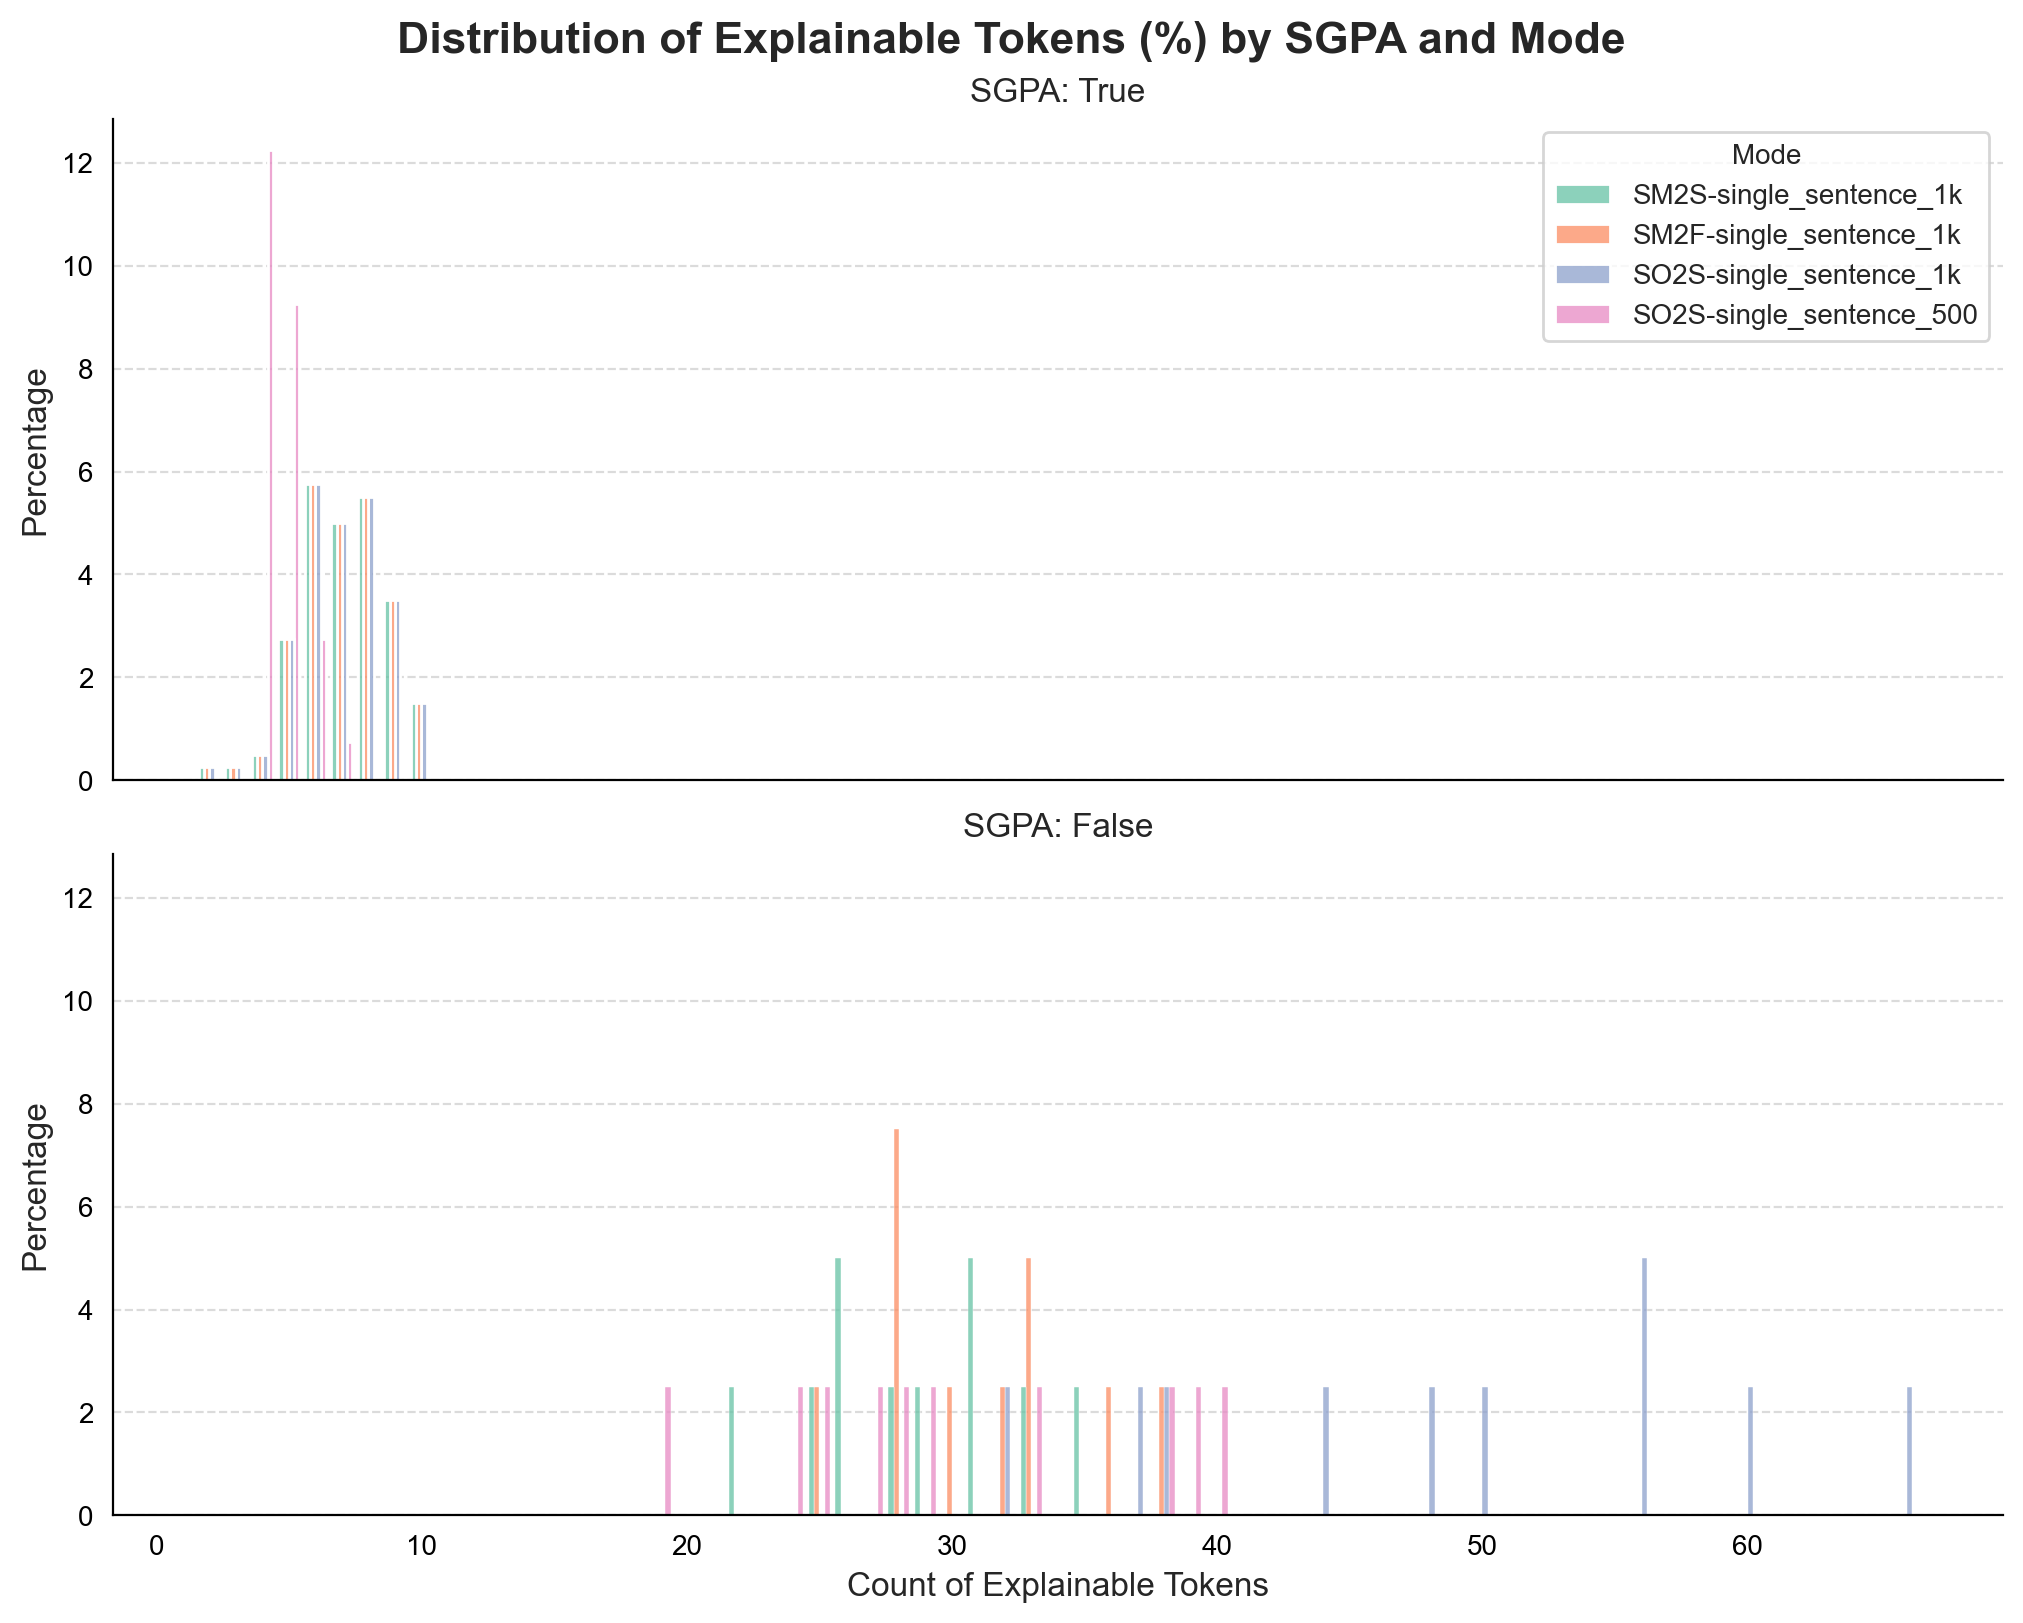

In [8]:
fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), sharex=True, sharey=True, constrained_layout=True
)

for i, sgpa in enumerate([True, False]):
    sgpa_df = df[df["sgpa"] == sgpa]
    plot_token_count_distribution(
        sgpa_df.rename(columns={"mode": "Mode"}),
        column="count_explainable_tokens",
        plot_ax=axes[i],
        hue="Mode",
        legend=i == 0,
    )
    axes[i].set_title(f"SGPA: {sgpa}")
    axes[i].label_outer()

fig.suptitle(
    "Distribution of Explainable Tokens (%) by SGPA and Mode",
    fontsize=16,
    fontweight="bold",
)
plt.savefig(f"{FIGURES_DIR}/token_count_distribution.png", bbox_inches="tight", dpi=300)

In [9]:
neyman_steps_distribution = df.groupby(["sgpa", "mode"])["neyman_steps"].value_counts(
    normalize=True
)
neyman_steps_distribution.unstack()

neyman_steps                       1     2
sgpa  mode                                
True  SM2S-single_sentence_1k   0.15  0.85
      SM2F-single_sentence_1k   0.15  0.85
      SO2S-single_sentence_1k   0.15  0.85
      SO2S-single_sentence_500  0.86  0.14
False SM2S-single_sentence_1k   0.00  1.00
      SM2F-single_sentence_1k   0.00  1.00
      SO2S-single_sentence_1k   0.00  1.00
      SO2S-single_sentence_500  0.00  1.00

In [10]:
summary_stats = df.groupby(["sgpa", "mode"])[["n_calls", "runtime_sec"]].agg(
    ["describe"]
)
summary_stats.stack(level=0).unstack(level=1)

describe                          \
                                    count                           
mode              SM2S-single_sentence_1k SM2F-single_sentence_1k   
sgpa                                                                
True  n_calls                       100.0                   100.0   
      runtime_sec                   100.0                   100.0   
False n_calls                        10.0                    10.0   
      runtime_sec                    10.0                    10.0   

                                                                    \
                                                                     
mode              SO2S-single_sentence_1k SO2S-single_sentence_500   
sgpa                                                                 
True  n_calls                       100.0                    100.0   
      runtime_sec                   100.0                    100.0   
False n_calls                        10.0                     10.0   
      runtime_sec                    10.0                     10.0   

                                                                   \
                                     mean                           
mode              SM2S-single_sentence_1k SM2F-single_sentence_1k   
sgpa                                                                
True  n_calls                   80.620000               80.740000   
      runtime_sec              142.353865              142.900695   
False n_calls                 1984.200000             2364.200000   
      runtime_sec             2415.950025             2820.716899   

                                                                    \
                                                                     
mode              SO2S-single_sentence_1k SO2S-single_sentence_500   
sgpa                                                                 
True  n_calls                   79.780000                21.700000   
      runtime_sec              137.602400                28.883378   
False n_calls                 6321.600000              2306.400000   
      runtime_sec             7362.077281              2653.585003   

                                                                   ...  \
                                      std                          ...   
mode              SM2S-single_sentence_1k SM2F-single_sentence_1k  ...   
sgpa                                                               ...   
True  n_calls                   59.007067               59.191629  ...   
      runtime_sec               88.255728               88.729974  ...   
False n_calls                  581.683725              648.562479  ...   
      runtime_sec              677.216019              772.353733  ...   

                                                                    \
                                      50%                            
mode              SO2S-single_sentence_1k SO2S-single_sentence_500   
sgpa                                                                 
True  n_calls                   66.000000                15.000000   
      runtime_sec              126.721007                25.150350   
False n_calls                 6091.000000              1924.000000   
      runtime_sec             7120.475275              2252.327513   

                                                                   \
                                      75%                           
mode              SM2S-single_sentence_1k SM2F-single_sentence_1k   
sgpa                                                                
True  n_calls                  122.500000              122.000000   
      runtime_sec              202.565200              202.770497   
False n_calls                 2317.000000             2628.500000   
      runtime_sec             2691.610559             3105.274570   

                                                                    \
                            

# Analysis

## Cumulative sum

Let's also have a look on how the cumulative sum curves look like for all samples.

In [11]:
df["sv_cumsum"] = df[SV_COL].apply(np.cumsum)
cumsums = df.groupby("row_index", group_keys=False)[
    ["sgpa", "mode", "row_index", "sv_cumsum"]
].apply(normalize_lengths)

In [12]:
plot_df = cumsums.explode("sv_cumsum").reset_index(drop=True)
plot_df["time (tokens)"] = plot_df.groupby(["sgpa", "mode", "row_index"]).cumcount()

plot_df["sv_cumsum"] = plot_df["sv_cumsum"].astype(float)
plot_df["sv_derivative"] = (
    plot_df.groupby(["sgpa", "mode", "row_index"])["sv_cumsum"].diff().fillna(0)
)

In [13]:
sns.set_theme(style="white")

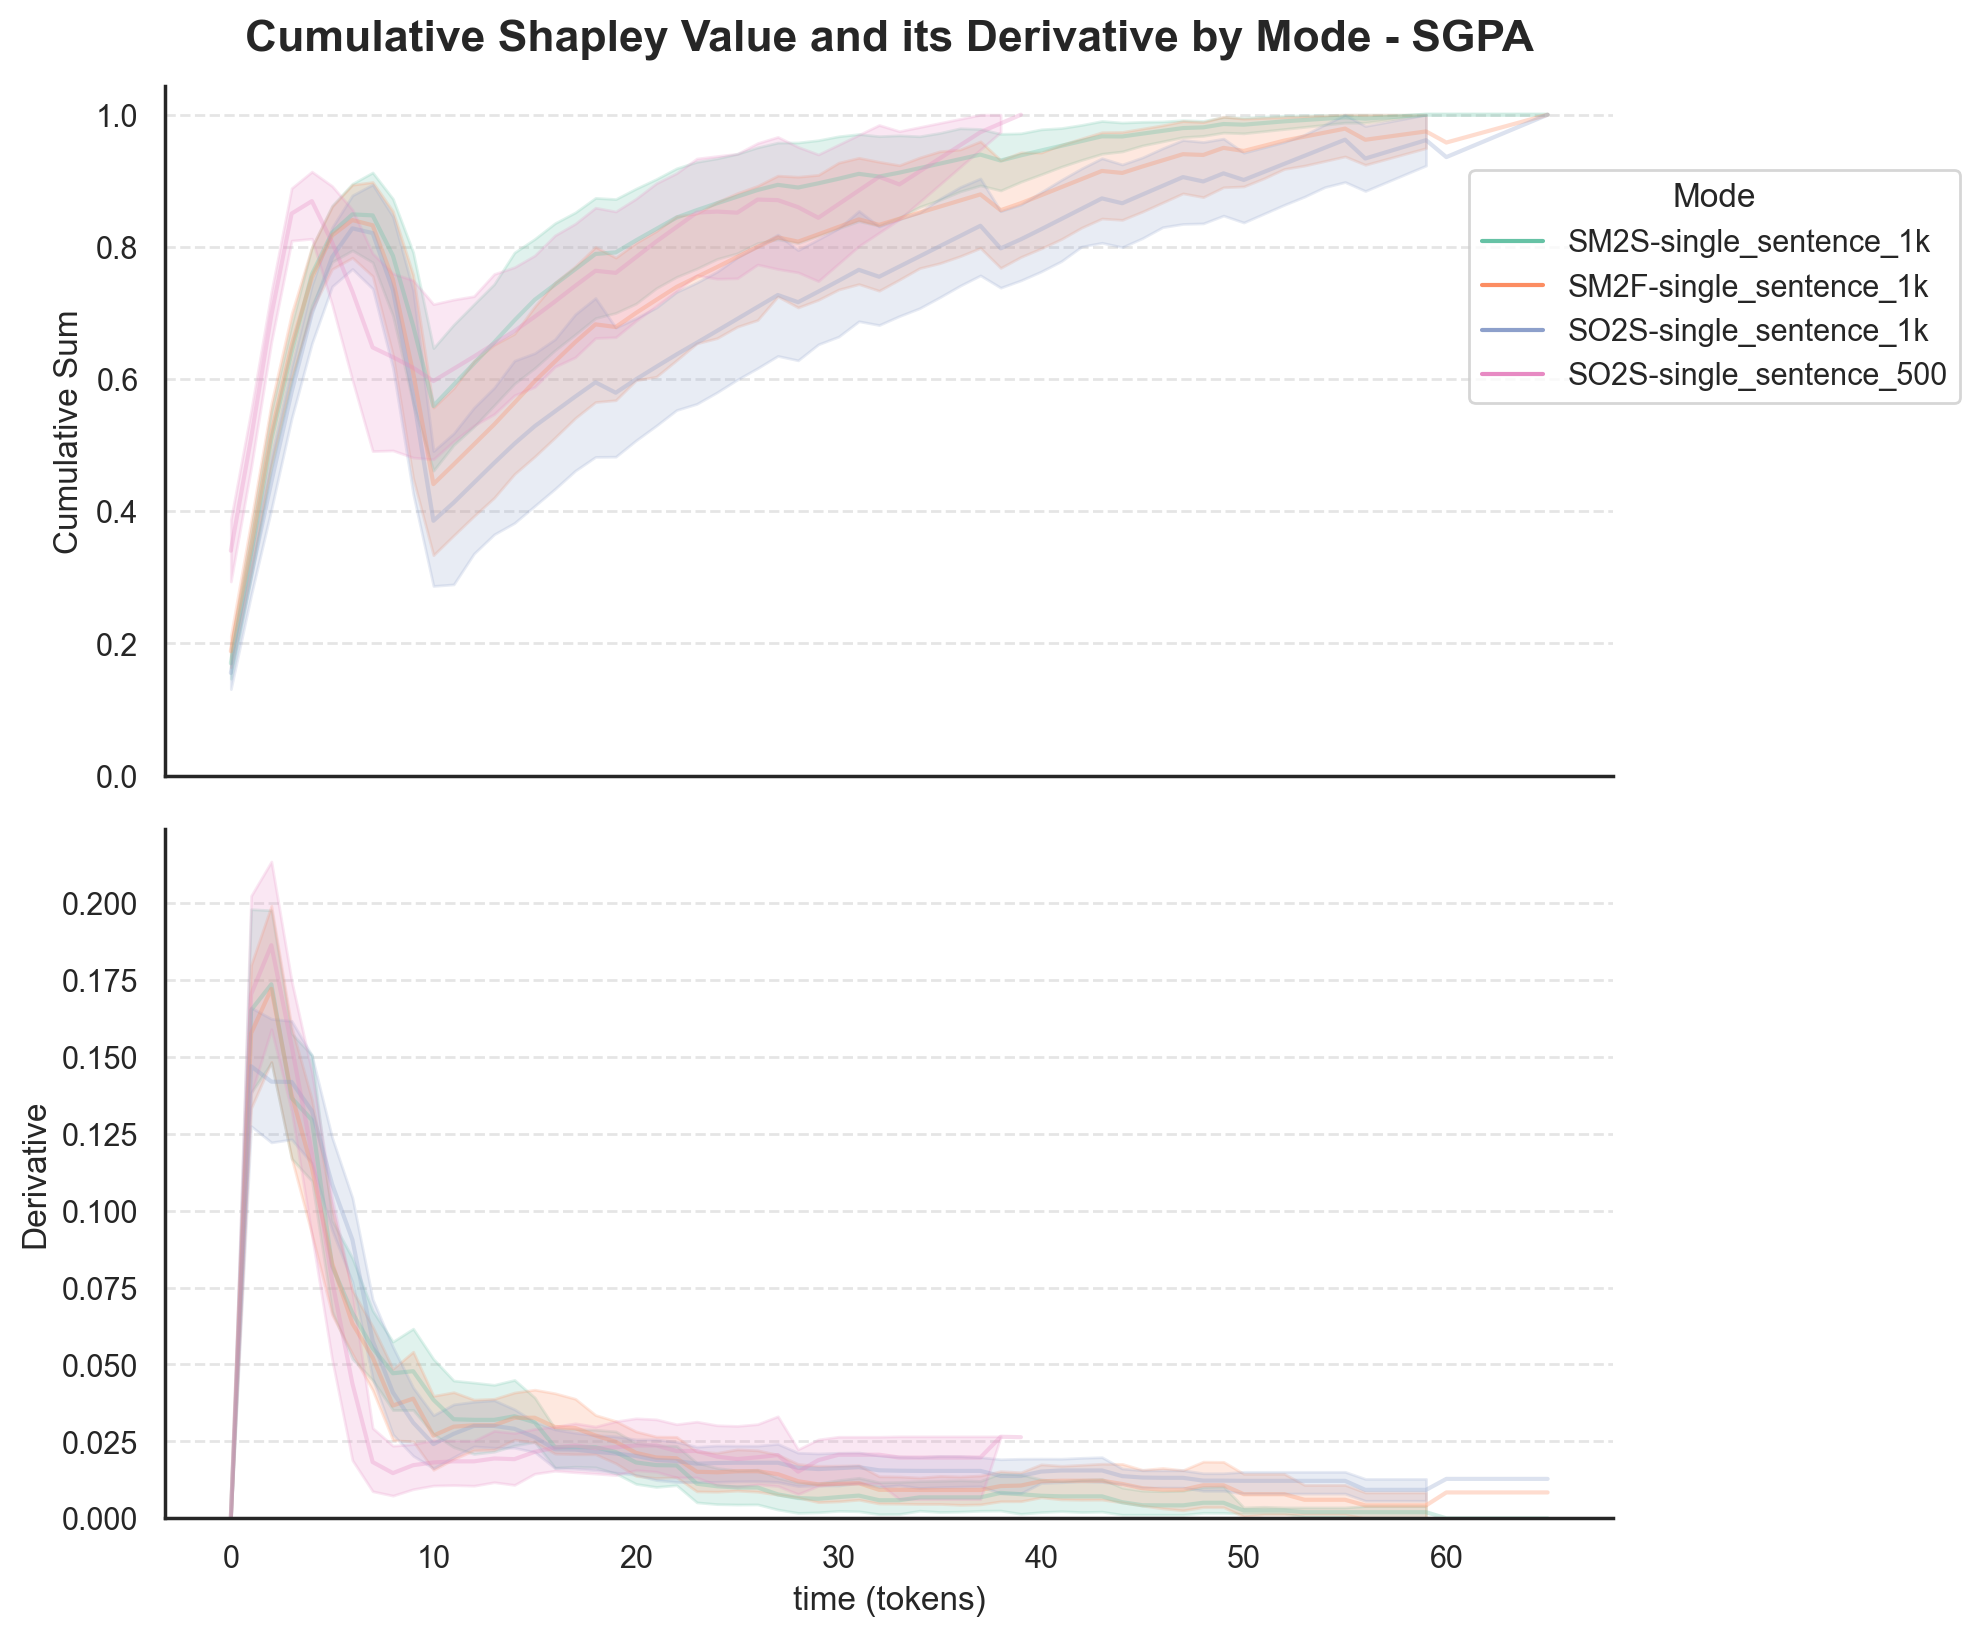

In [14]:
plot_importance_cumsum_and_derivative(plot_df[plot_df["sgpa"]])
plt.title(
    "Cumulative Shapley Value and its Derivative by Mode - SGPA",
    fontsize=16,
    fontweight="bold",
    pad=280,
)
plt.savefig(
    f"{FIGURES_DIR}/cumulative_shapley_and_derivative_1.png",
    bbox_inches="tight",
    dpi=300,
)

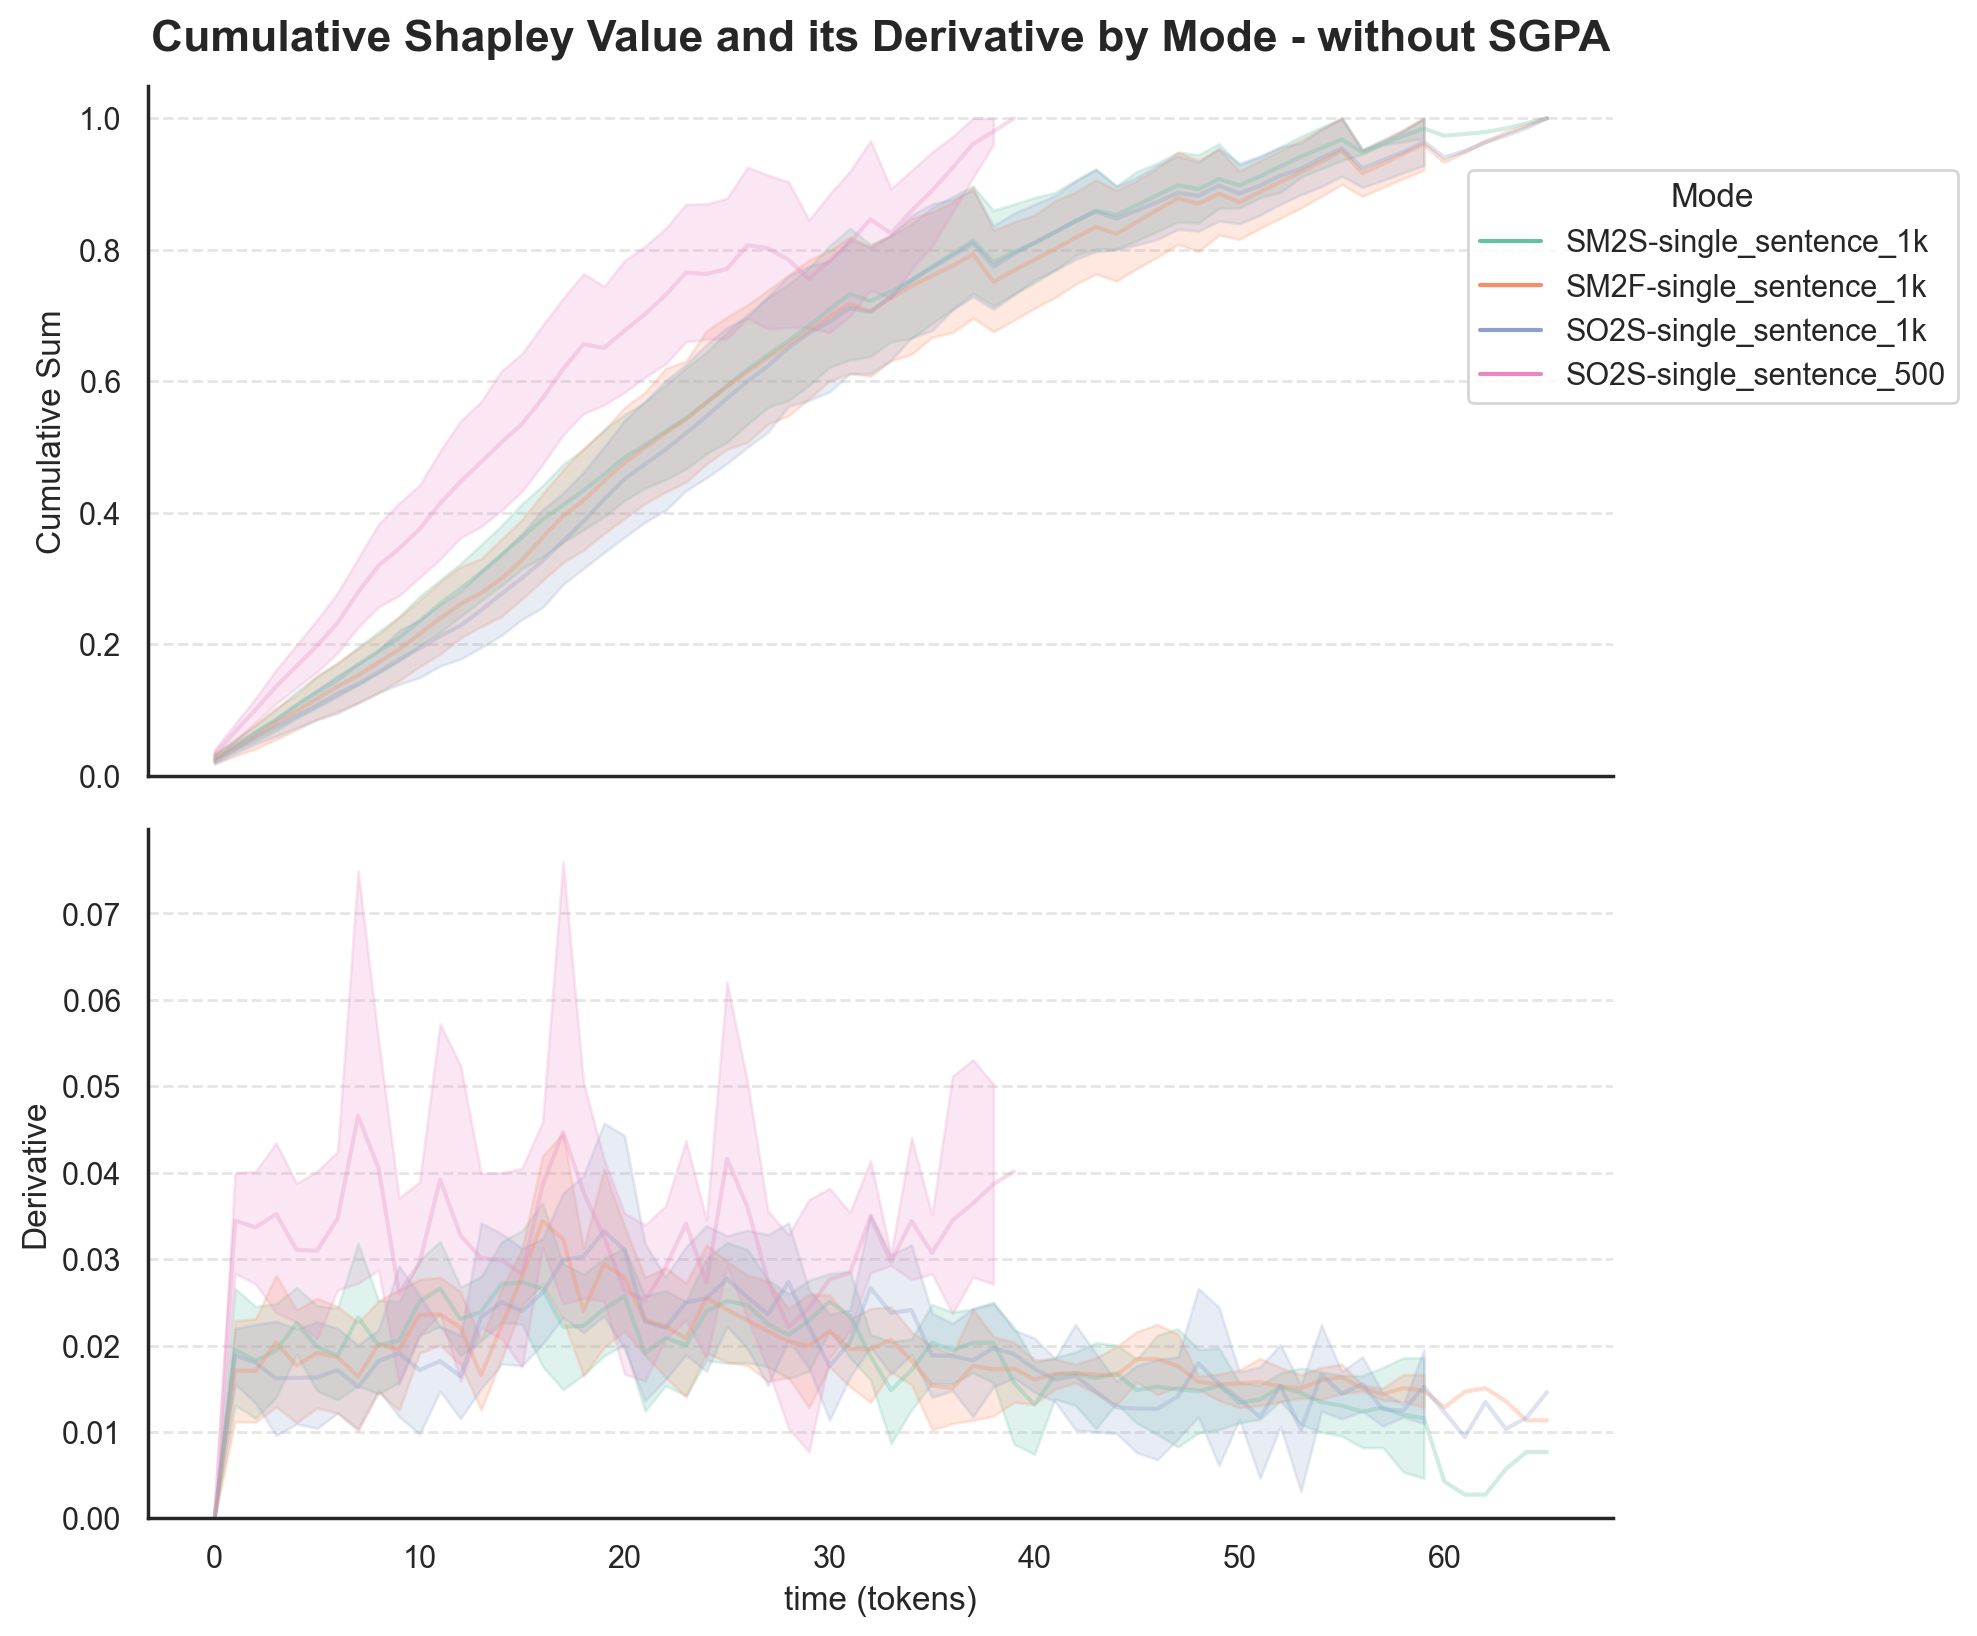

In [15]:
plot_importance_cumsum_and_derivative(
    plot_df[plot_df["sgpa"] == False]  # noqa: E712
)  # noqa: E712
plt.title(
    "Cumulative Shapley Value and its Derivative by Mode - without SGPA",
    fontsize=16,
    fontweight="bold",
    pad=280,
)
plt.savefig(
    f"{FIGURES_DIR}/cumulative_shapley_and_derivative_2.png",
    bbox_inches="tight",
    dpi=300,
)

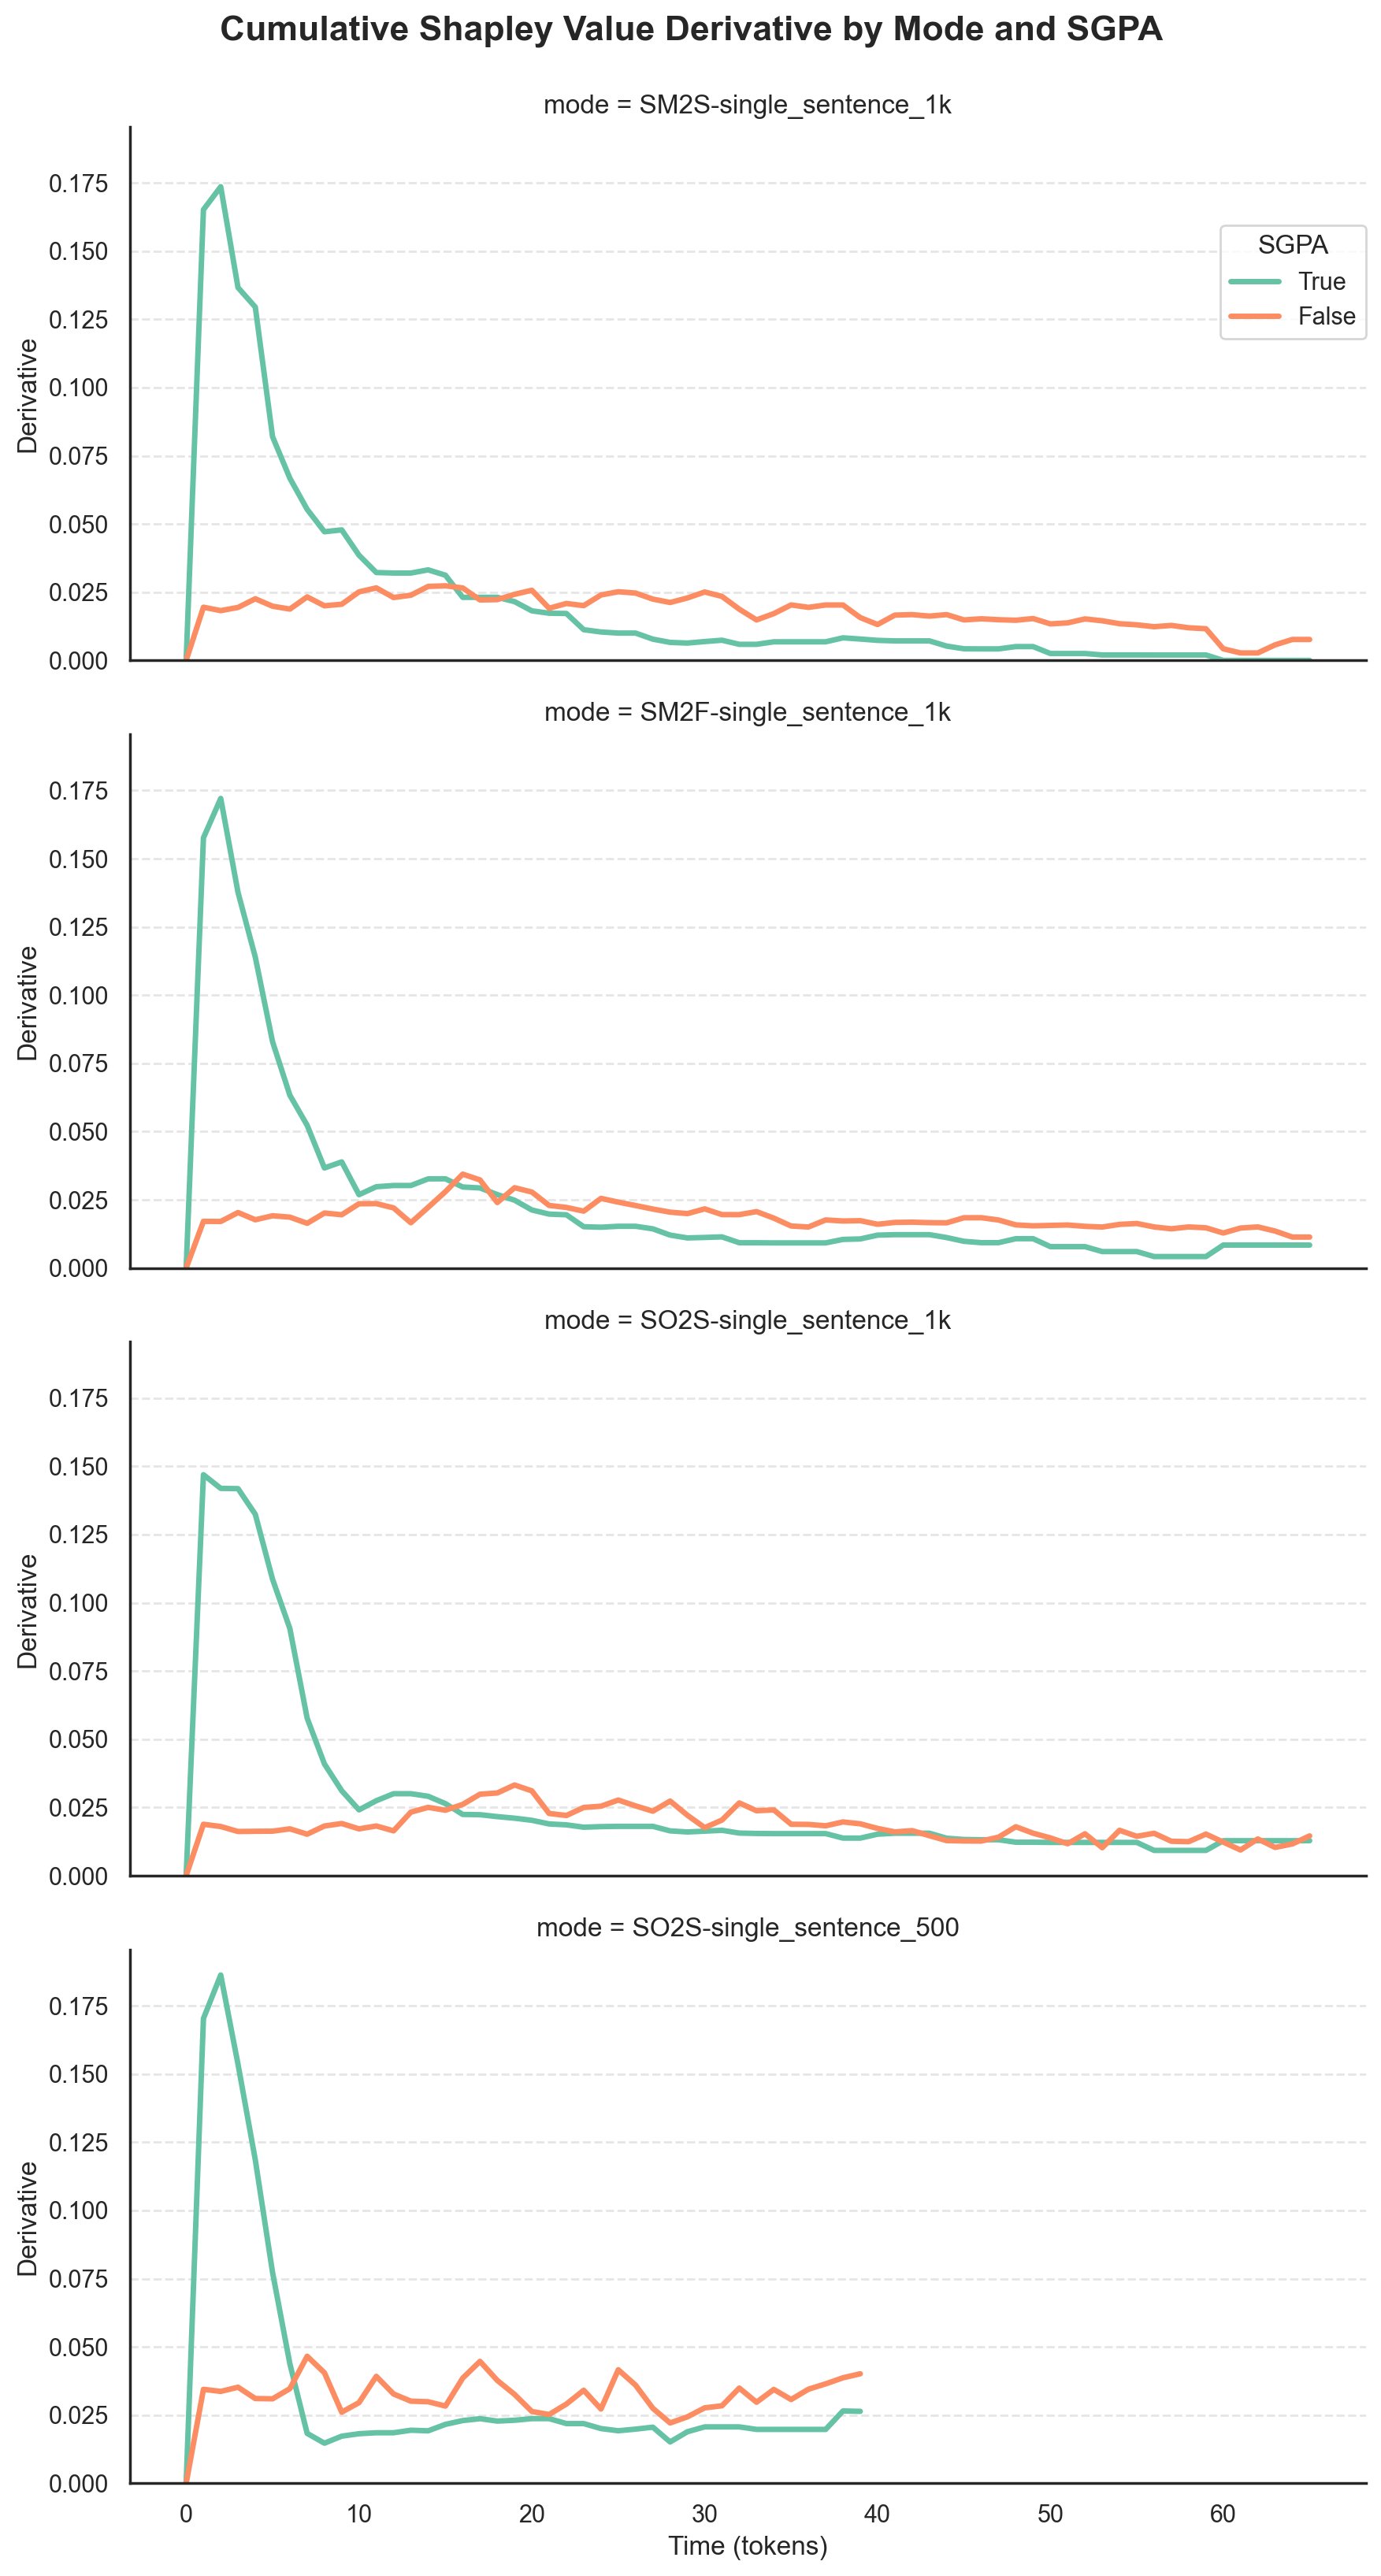

In [16]:
plot_derivative(
    plot_df.rename(columns={"sgpa": "SGPA"}),
    errorbar=None,
    alpha=1.0,
    linewidth=2.5,
    hue="SGPA",
)
plt.suptitle(
    "Cumulative Shapley Value Derivative by Mode and SGPA",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.savefig(
    f"{FIGURES_DIR}/cumulative_shapley_derivative_3.png", bbox_inches="tight", dpi=300
)

## General tests

Do Shapley values differ significantly?

In [17]:
def recolumnize(_df: pd.DataFrame) -> pd.DataFrame:
    """Recolumnize Mode and Language columns from tuples."""
    _df["Sgpa_1"] = _df["Mode_1"].apply(lambda x: x[1] if isinstance(x, tuple) else x)
    _df["Sgpa_2"] = _df["Mode_2"].apply(lambda x: x[1] if isinstance(x, tuple) else x)
    _df["Mode_1"] = _df["Mode_1"].apply(lambda x: x[0] if isinstance(x, tuple) else x)
    _df["Mode_2"] = _df["Mode_2"].apply(lambda x: x[0] if isinstance(x, tuple) else x)
    return _df


def filter_results(_df: pd.DataFrame) -> pd.DataFrame:
    """Filter results to only significant adjusted p-values."""
    return _df[_df["Significant_Adj"]][
        [
            "metric",
            "Sgpa_1",
            "Sgpa_2",
            "Mode_1",
            "Mode_2",
            "P_Value",
            "Significant_Adj",
            "Shapiro_Significant",
            "Cohens_dz",
        ]
    ].sort_values(by=["metric", "Sgpa_1", "Sgpa_2", "Mode_1", "Mode_2"])

In [18]:
results = perform_advanced_ttest(
    results_df,
    grp_by_cols=["row_index", "mode", "sgpa"],
    value_col=SV_COL,
    unstack=["mode", "sgpa"],
)

results = recolumnize(results)
results.to_csv(f"{STATS_DIR}/mean_ttest_results.csv")
results = filter_results(results)

/Users/pawel.pozorski/Desktop/MLLM-Shap/experiments/analysis/src/stats.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_norm = stats.shapiro(diff)
/Users/pawel.pozorski/Desktop/MLLM-Shap/experiments/analysis/src/stats.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_norm = stats.shapiro(diff)
/Users/pawel.pozorski/Desktop/MLLM-Shap/experiments/analysis/src/stats.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_norm = stats.shapiro(diff)
/Users/pawel.pozorski/Desktop/MLLM-Shap/experiments/analysis/src/stats.py:34: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_nor

In [19]:
results

,metric,Sgpa_1,Sgpa_2,Mode_1,Mode_2,P_Value,Significant_Adj,Shapiro_Significant,Cohens_dz
96,entropy,True,False,SM2F-single_sentence_1k,SM2F-single_sentence_1k,<0.01,True,False,-1.45
98,entropy,True,False,SM2F-single_sentence_1k,SO2S-single_sentence_1k,<0.01,True,False,-1.42
87,entropy,True,False,SM2S-single_sentence_1k,SM2F-single_sentence_1k,<0.01,True,False,-1.77
85,entropy,True,False,SM2S-single_sentence_1k,SM2S-single_sentence_1k,<0.01,True,False,-1.61
89,entropy,True,False,SM2S-single_sentence_1k,SO2S-single_sentence_1k,<0.01,True,False,-1.66
97,entropy,True,True,SM2F-single_sentence_1k,SO2S-single_sentence_1k,<0.01,True,True,-0.43
88,entropy,True,True,SM2S-single_sentence_1k,SO2S-single_sentence_1k,<0.01,True,True,-0.42
31,gini,True,True,SM2F-single_sentence_1k,SO2S-single_sentence_1k,<0.01,True,True,0.41
22,gini,True,True,SM2S-single_sentence_1k,SO2S-single_sentence_1k,<0.01,True,True,0.40
79,max,False,True,SM2F-single_sentence_1k,SO2S-single_sentence_1k,<0.01,True,False,-2.14


## Entropy

/var/folders/8l/l8x5k0qj70d2ttx81bkn85n40000gn/T/ipykernel_12319/1432593349.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["True", "False"])


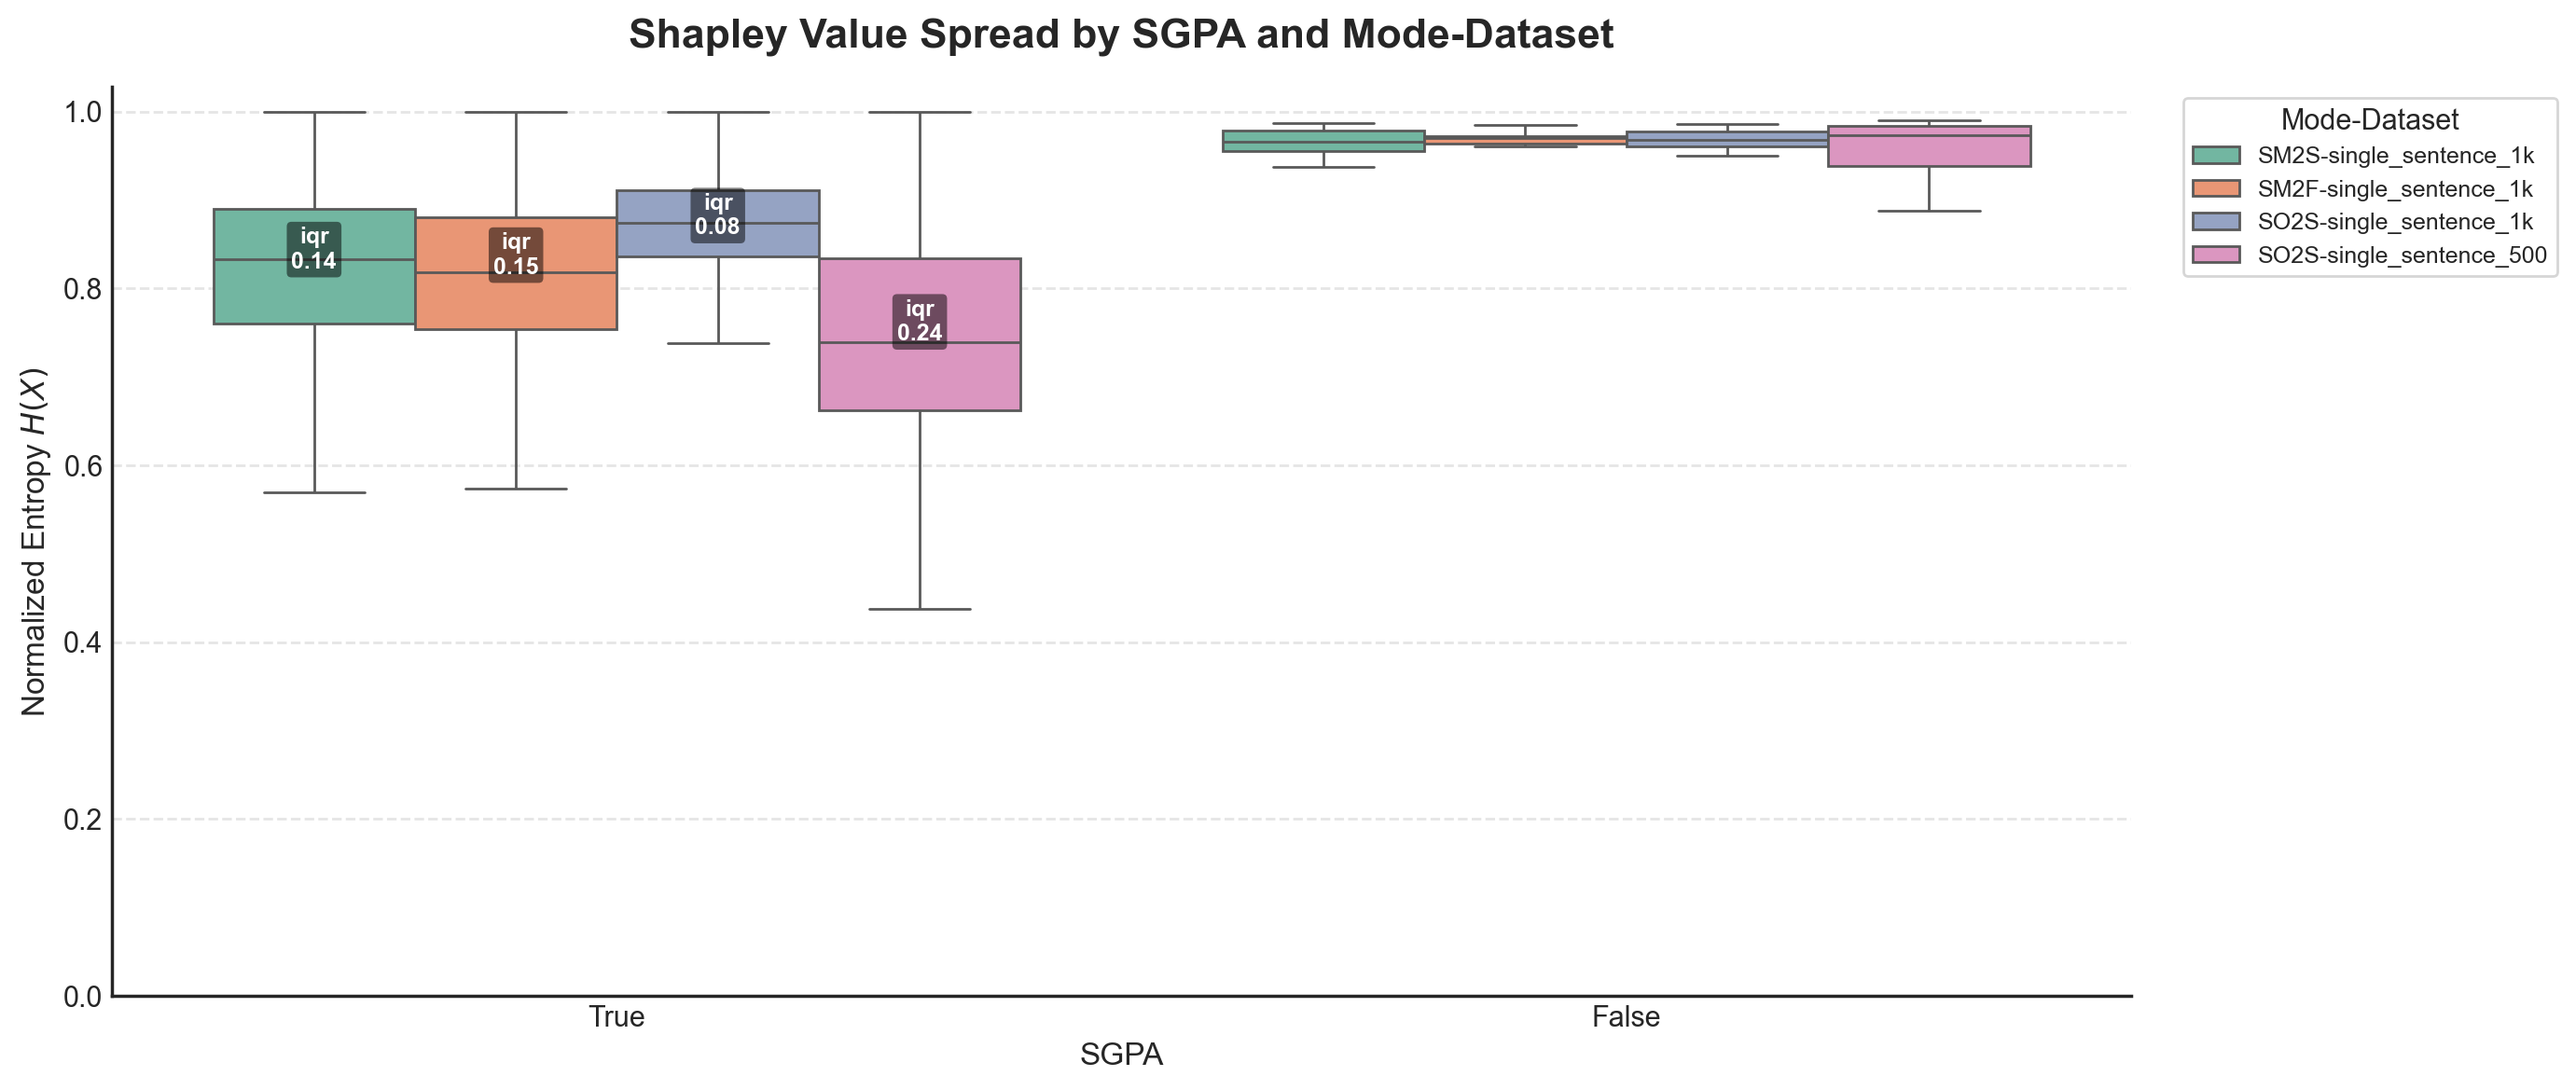

In [20]:
df["sv_entropy"] = df["sv"].apply(calculate_normalized_entropy)
stats = df.groupby("mode")["sv_entropy"].agg(
    median="median", iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

plt.figure(figsize=(14, 6))
ax = sns.boxplot(
    data=df,
    x="sgpa",
    y="sv_entropy",
    hue="mode",
    hue_order=MODE_DATASET_ORDER,
    palette="Set2",
    showfliers=False,
)

sgpa_order = [True, False]
mode_to_offset = {
    mode: (idx - (len(MODE_DATASET_ORDER) - 1) / 2) * 0.8 / len(MODE_DATASET_ORDER)
    for idx, mode in enumerate(MODE_DATASET_ORDER)
}

for mode, row in stats.iterrows():
    if np.isnan(row["median"]):
        continue
    mode_rows = df[df["mode"] == mode]
    if mode_rows.empty:
        continue

    target_sgpa = mode_rows["sgpa"].mode().iloc[0]
    x_pos = sgpa_order.index(target_sgpa) + mode_to_offset[mode]
    ax.text(
        x_pos,
        row["median"],
        f"iqr\n{row['iqr']:.2f}",
        ha="center",
        va="center",
        fontweight="bold",
        size=9,
        color="white",
        bbox={
            "facecolor": "black",
            "alpha": 0.5,
            "edgecolor": "none",
            "boxstyle": "round,pad=0.2",
        },
    )

plt.title(
    "Shapley Value Spread by SGPA and Mode-Dataset",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("SGPA", fontsize=12)
plt.ylabel("Normalized Entropy $H(X)$", fontsize=12)
ax.set_xticklabels(["True", "False"])
plt.ylim(bottom=0)
sns.despine(top=True, right=True)
ax.tick_params(axis="both", which="both", length=0)
ax.legend(
    title="Mode-Dataset",
    title_fontsize=11,
    fontsize=9,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sv_entropy_by_mode.png", bbox_inches="tight", dpi=300)

## Over time

In [21]:
results_df["token_pos_idx"] = results_df.groupby(
    ["mode", "sgpa", "row_index"]
).cumcount()
results_df["max_idx"] = results_df.groupby(["mode", "sgpa", "row_index"])[
    "token_pos_idx"
].transform("max")
results_df.loc[results_df["max_idx"] == 0, "max_idx"] = 1
results_df["normalized_position"] = results_df["token_pos_idx"] / results_df["max_idx"]

In [22]:
sns.set_theme(style="white")

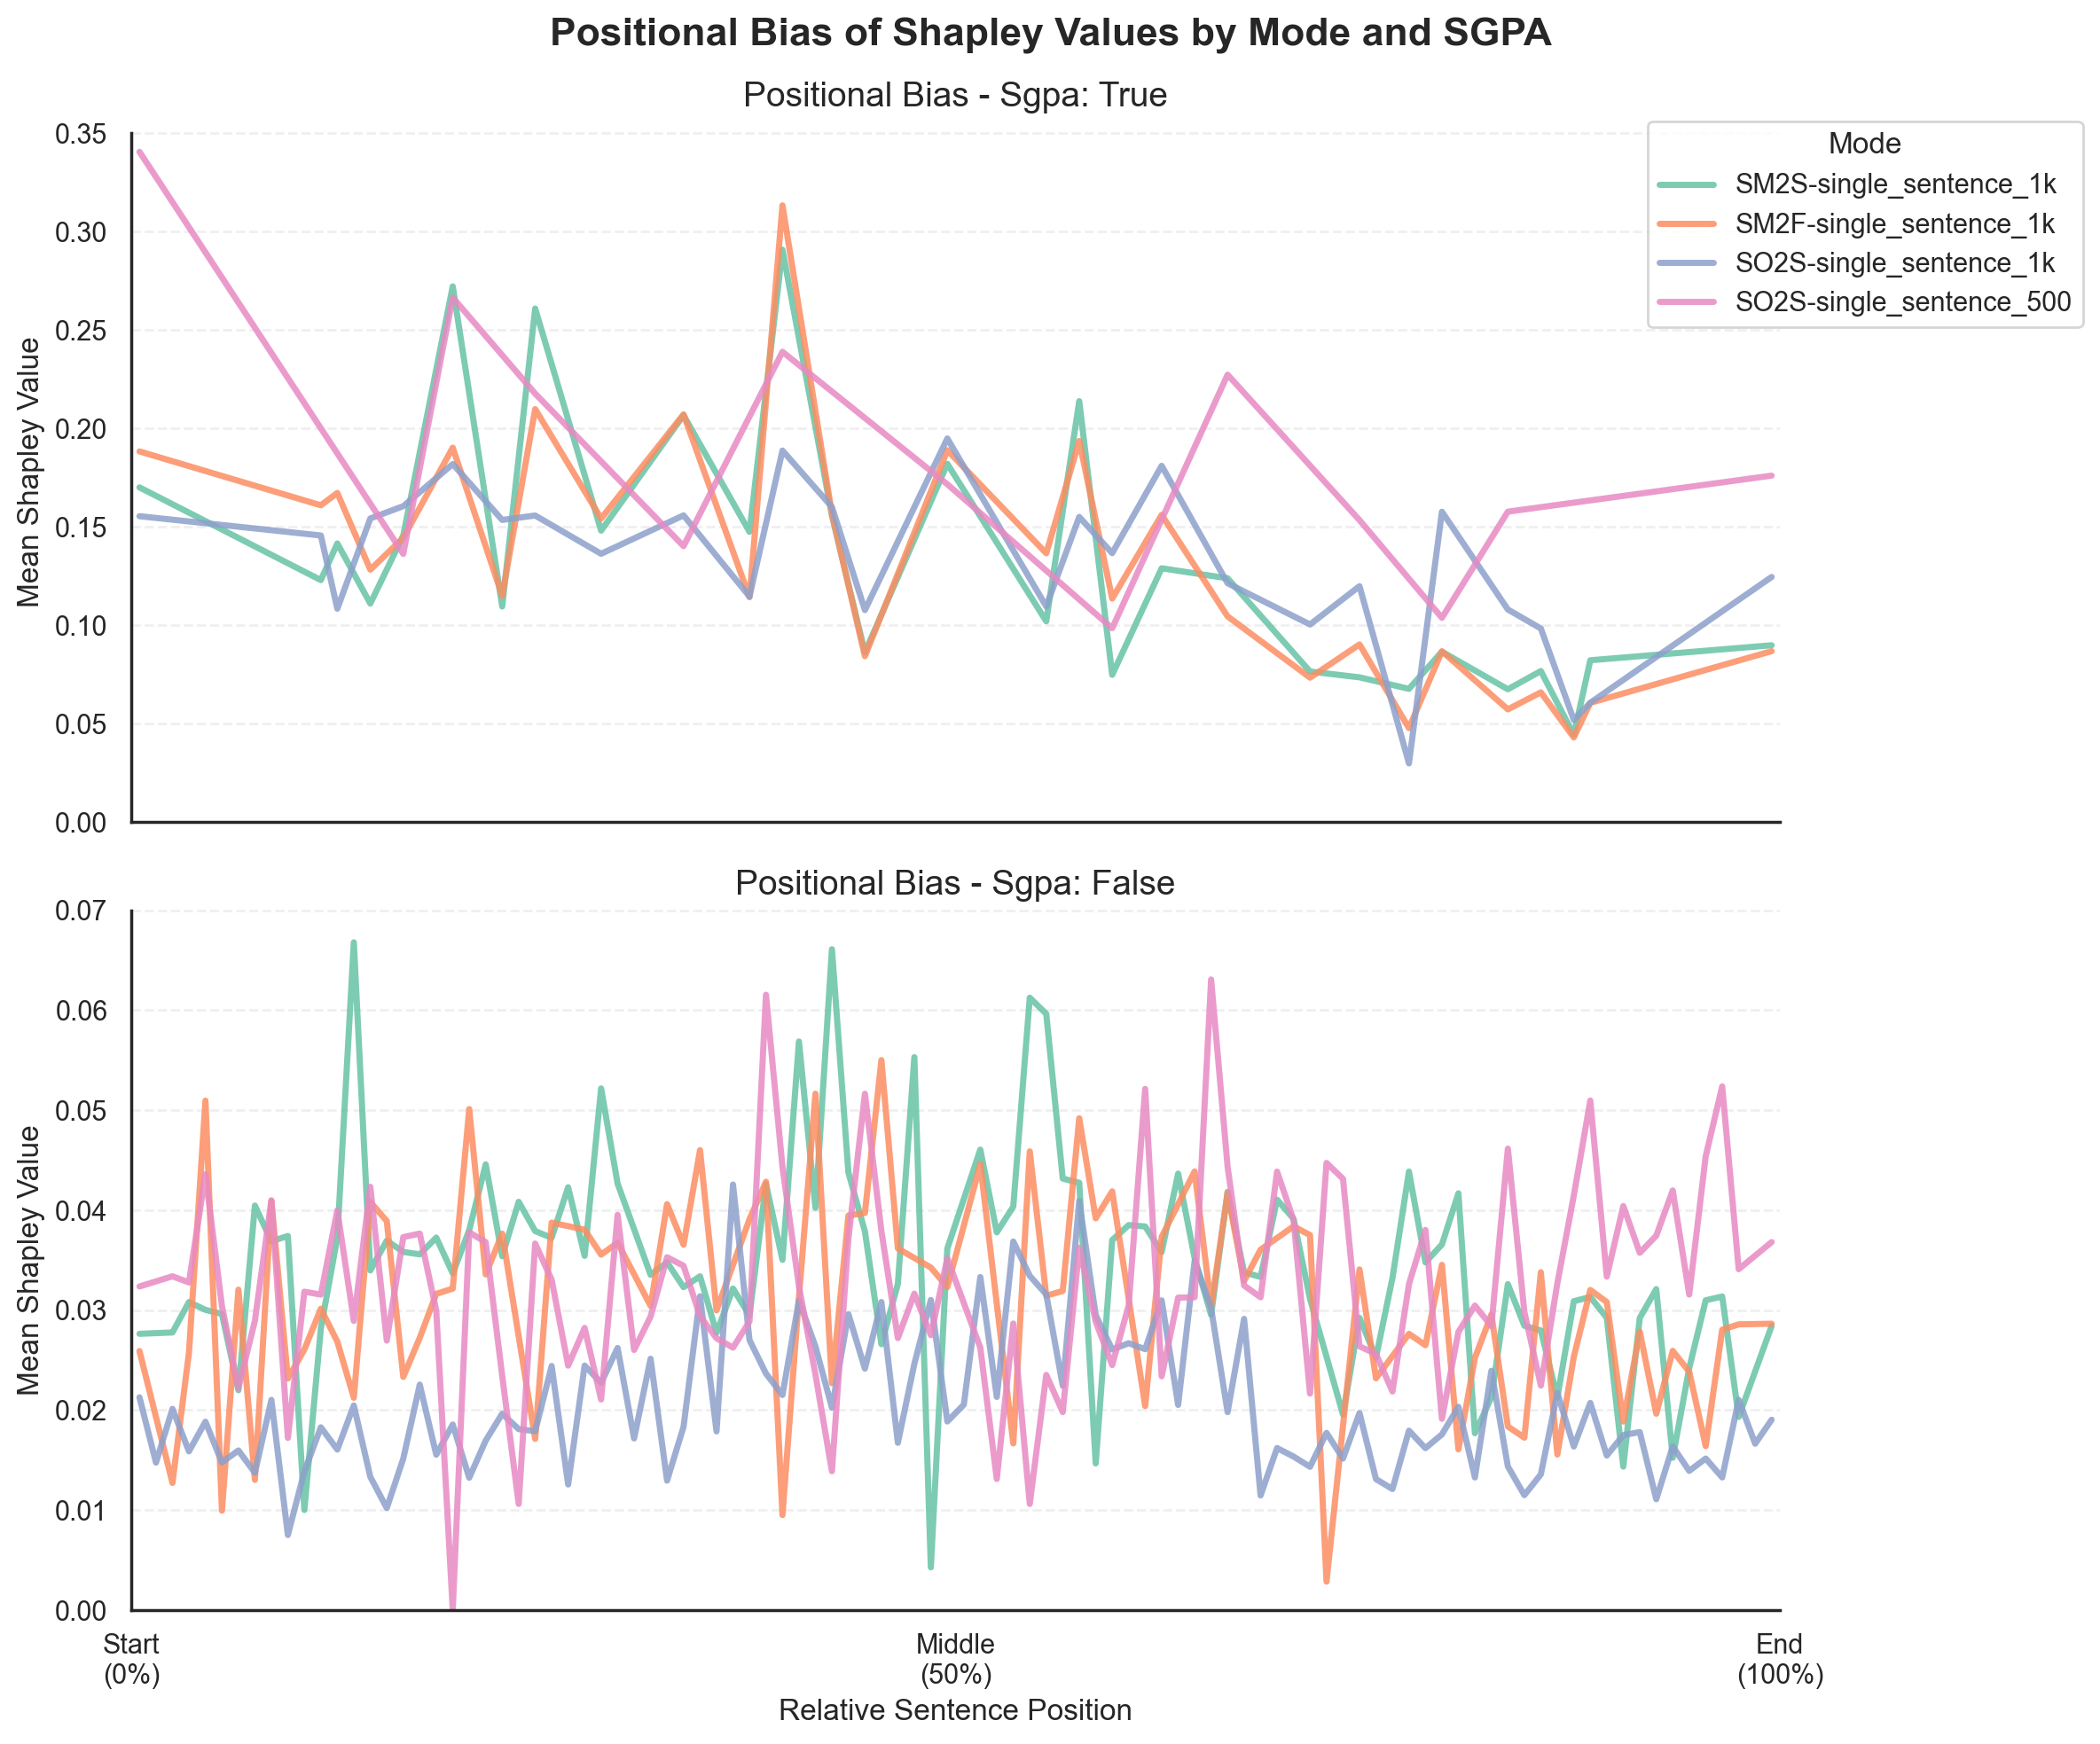

In [23]:
sgpas = df["sgpa"].unique()
n_langs = len(sgpas)
fig, axes = plt.subplots(n_langs, 1, figsize=(12, 5 * n_langs), sharex=True)
if n_langs == 1:
    axes = [axes]

for i, (ax, sgpa) in enumerate(zip(axes, sgpas)):
    data = results_df[(results_df["sgpa"] == sgpa)]

    plot_attribution_trend(data, n_bins=100, ax=ax, legend=i == 0)
    ax.set_title(f"Positional Bias - Sgpa: {sgpa}", fontsize=14)

fig.suptitle(
    "Positional Bias of Shapley Values by Mode and SGPA", fontsize=16, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/positional_bias_smooth_1.png", bbox_inches="tight", dpi=300)